In [1]:
import numpy as np
import pandas as pd
import sklearn, sklearn.preprocessing, sklearn.model_selection, sklearn.linear_model, sklearn.metrics, sklearn.feature_selection, sklearn.ensemble
import matplotlib.pyplot as plt
import seaborn as sns

# Numbers display set-up
pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# 1) Data Preparation

We are going to use following dataset to train a model for predicting a yearly salary (total compensation) when we are hiring a new employee. This model can help to HR department. Credit to Worksday's tutorial on ML Prague.

In [3]:
df = pd.read_csv('datasets/hr-data.csv')
df.shape

(5000, 24)

In [4]:
df.head(3)

,compa_ratio,compa_ratio_range,cost_center,country,current_rating,ethnicity,gender,generation,high_performer,high_potential,hiring_source,is_leader,is_manager,job_family_group,job_level,job_profile,length_of_service,location,management_level,region,single_job_family,tenure_category,total_compensation,age
0,1.545,Above Compa-Ratio,AMER - United States of America,United States of America,4 - Exceeds Expectations,Asian,Female,Generation X (1965-1980),False,False,Referral,True,True,Executive,M9,Executive Management - Chief Executive Officer,26.934,San Francisco,Chief Executive Officer,AMER,Executive Management,15+ Years,772400,57.000
1,1.021,At Compa-Ratio,AMER - United States of America,United States of America,3 - Meets Expectations,White,Male,Generation Z (1997 and onwards),False,True,Referral,False,False,Development,P2,IT - Product Development - P2 Business Analytics,1.844,New York,Individual Contributor,AMER,IT - Product Development,01-02 Years,68900,25.000
2,0.981,At Compa-Ratio,Global Support - Asia/Pac,South Korea,5 - Outstanding Performance,Asian,Male,Generation Y/Millenials (1981-1996),True,False,Recruiter,False,False,Development,P3,IT - Product Development - P3 Data Scientist,2.192,Seoul,Individual Contributor,APAC,IT - Product Development,02-05 Years,53200,33.000


In [5]:
df.describe(include="all")

,compa_ratio,compa_ratio_range,cost_center,country,current_rating,ethnicity,gender,generation,high_performer,high_potential,hiring_source,is_leader,is_manager,job_family_group,job_level,job_profile,length_of_service,location,management_level,region,single_job_family,tenure_category,total_compensation,age
count,5000.000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000.000,5000,5000,5000,5000,5000,5000.000,5000.000
unique,NaN,3,5,6,5,5,2,4,2,2,6,2,2,5,13,90,NaN,19,6,3,11,6,NaN,NaN
top,NaN,Above Compa-Ratio,AMER - United States of America,United States of America,4 - Exceeds Expectations,White,Female,Generation Y/Millenials (1981-1996),False,False,Referral,False,False,Development,P4,Board Management - Senior Board Associate,NaN,San Francisco,Individual Contributor,AMER,IT - Product Development,05-10 Years,NaN,NaN
freq,NaN,3284,1275,1275,1013,2282,2500,3364,3992,4227,1531,4674,4409,1476,1334,242,NaN,876,3913,2515,1309,1359,NaN,NaN
mean,1.169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.997,NaN,NaN,NaN,NaN,NaN,131567.360,36.859
std,0.227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.745,NaN,NaN,NaN,NaN,NaN,107949.422,10.741
min,0.639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003,NaN,NaN,NaN,NaN,NaN,24600.000,21.000
25%,0.990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.595,NaN,NaN,NaN,NaN,NaN,67500.000,29.000
50%,1.173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.699,NaN,NaN,NaN,NaN,NaN,104300.000,34.000
75%,1.352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.648,NaN,NaN,NaN,NaN,NaN,152700.000,40.000


In [6]:
df.tenure_category.value_counts().index

Index(['05-10 Years', '02-05 Years', '10-15 Years', '15+ Years', '00-01 Years',
       '01-02 Years'],
      dtype='object', name='tenure_category')

In [7]:
df.replace(np.nan, "nan", regex=True, inplace=True)
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['compa_ratio_range', 'cost_center', 'country', 'current_rating',
       'ethnicity', 'gender', 'generation', 'hiring_source',
       'job_family_group', 'job_level', 'job_profile', 'location',
       'management_level', 'region', 'single_job_family', 'tenure_category'],
      dtype='object')

In [8]:
ordinal_columns_category_order_dict = {
    'compa_ratio_range': ['Below Compa-Ratio', 'At Compa-Ratio', 'Above Compa-Ratio'],
    'current_rating': ['1 - Unsatisfactory', '2 - Needs Improvement', '3 - Meets Expectations', '4 - Exceeds Expectations', '5 - Outstanding Performance'],
    'tenure_category': ['00-01 Years', '01-02 Years', '02-05 Years', '05-10 Years', '10-15 Years', '15+ Years']
}

In [9]:
df_encoded = df.select_dtypes(exclude=["object"]).copy()
for col in ['high_performer', 'high_potential', 'is_leader', 'is_manager']:
    df_encoded[col] = df_encoded[col].astype(int)
df_encoded.head()

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,total_compensation,age
0,1.545,0,0,1,1,26.934,772400,57.000
1,1.021,0,1,0,0,1.844,68900,25.000
2,0.981,1,0,0,0,2.192,53200,33.000
3,1.342,0,1,0,0,18.518,204600,45.000
4,1.290,0,0,0,0,1.416,70000,32.000


In [10]:
ordinal_encoder = sklearn.preprocessing.OrdinalEncoder(categories=[ordinal_columns_category_order_dict[column] for column in ordinal_columns_category_order_dict.keys()])
df_encoded = df_encoded.join(pd.DataFrame(ordinal_encoder.fit_transform(df[ordinal_columns_category_order_dict.keys()]), index=df.index, columns=ordinal_columns_category_order_dict.keys()))
df_encoded.head()

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,total_compensation,age,compa_ratio_range,current_rating,tenure_category
0,1.545,0,0,1,1,26.934,772400,57.000,2.000,3.000,5.000
1,1.021,0,1,0,0,1.844,68900,25.000,1.000,2.000,1.000
2,0.981,1,0,0,0,2.192,53200,33.000,1.000,4.000,2.000
3,1.342,0,1,0,0,18.518,204600,45.000,2.000,1.000,5.000
4,1.290,0,0,0,0,1.416,70000,32.000,2.000,2.000,1.000


In [11]:
nominal_columns = [column for column in categorical_columns if column not in ordinal_columns_category_order_dict.keys()]
df_encoded = df_encoded.join(pd.get_dummies(df[nominal_columns], prefix_sep="="))
df_encoded.head()

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,total_compensation,age,compa_ratio_range,current_rating,tenure_category,cost_center=AMER - Canada,cost_center=AMER - United States of America,cost_center=EMEA - France,cost_center=EMEA - United Kingdom,cost_center=Global Support - Asia/Pac,country=Canada,country=France,country=Singapore,country=South Korea,country=United Kingdom,country=United States of America,ethnicity=American Indian or Alaska Native,ethnicity=Asian,ethnicity=Black or African American,ethnicity=Hispanic,ethnicity=White,gender=Female,gender=Male,generation=Baby Boomers (1946-1964),generation=Generation X (1965-1980),generation=Generation Y/Millenials (1981-1996),generation=Generation Z (1997 and onwards),hiring_source=Agency,hiring_source=Corporate Website,hiring_source=Internal,hiring_source=Linkedin,hiring_source=Recruiter,hiring_source=Referral,job_family_group=Development,job_family_group=Executive,job_family_group=Finance,job_family_group=Sales,job_family_group=Services,job_level=M2,job_level=M3,job_level=M4,job_level=M5,job_level=M6,job_level=M7,job_level=M8,job_level=M9,job_level=P1,job_level=P2,job_level=P3,job_level=P4,job_level=P5,job_profile=Board Management - Executive Vice President,job_profile=Board Management - Principal Board Associate,job_profile=Board Management - Senior Board Associate,job_profile=Board Management - Vice President,job_profile=Executive Management - Chief Executive Officer,job_profile=Executive Management - Executive Vice President,job_profile=Executive Management - Principal Operations Executive,job_profile=Executive Management - Senior Operations Executive,job_profile=Executive Management - Vice President,job_profile=FA - Accounting - P2 Accounting Settlement Specialist,job_profile=FA - Accounting - P2 Finance Analyst,job_profile=FA - Accounting - P3 Accounting Settlement Specialist,job_profile=FA - Accounting - P3 Finance Analyst,job_profile=FA - Accounting - Principal Accounting Settlement Specialist,job_profile=FA - Accounting - Principal Finance Analyst,job_profile=FA - Accounting - Senior Accounting Settlement Specialist,job_profile=FA - Accounting - Senior Finance Analyst,job_profile=FA - Management - Associate Manager,job_profile=FA - Management - Director,job_profile=FA - Management - Manager,job_profile=FA - Management - Senior Director,job_profile=FA - Management - Senior Manager,job_profile=Human Resources - Associate Manager,job_profile=Human Resources - Director,job_profile=Human Resources - Manager,job_profile=Human Resources - P2 Human Resources Analyst,job_profile=Human Resources - P2 Human Resources Consultant,job_profile=Human Resources - P3 Human Resources Analyst,job_profile=Human Resources - P3 Human Resources Consultant,job_profile=Human Resources - Principal Human Resources Analyst,job_profile=Human Resources - Principal Human Resources Consultant,job_profile=Human Resources - Senior Director,job_profile=Human Resources - Senior Human Resources Analyst,job_profile=Human Resources - Senior Human Resources Consultant,job_profile=Human Resources - Senior Manager,job_profile=Human Resources - Vice President,job_profile=IT - Product Development - P1 Business Analytics,job_profile=IT - Product Development - P1 Data Scientist,job_profile=IT - Product Development - P1 QA,job_profile=IT - Product Development - P1 Software Engineer,job_profile=IT - Product Development - P2 Business Analytics,job_profile=IT - Product Development - P2 Data Scientist,job_profile=IT - Product Development - P2 QA,job_profile=IT - Product Development - P2 Software Engineer,job_profile=IT - Product Development - P3 Business Analytics,job_profile=IT - Product Development - P3 Data Scientist,job_profile=IT - Product Development - P3 QA,job_profile=IT - Product Development - P3 Software Engineer,job_profile=IT - Product Development - Principal Business Analytics,job_profile=IT - Product Development - Principal Data Scientist,job_profile=IT - Product Devel

In [12]:
df_encoded.shape

(5000, 186)

# 2) Linear Regression

There are a few assumptions associated with a linear regression model:

* Linearity: The relationship between X and Y is linear.
* Homoscedasticity: The variance of residual is the same for any value of X.
* No multicollinearity: There is no high correlations among two or more independent variables.
* Independence: Observations are independent of each other.
* Normality: For any fixed value of X, Y is normally distributed.

In [13]:
X_data = df_encoded.drop('total_compensation', axis=1)
y_data = df_encoded['total_compensation']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X_data, y_data, test_size=0.20, random_state=12
)
column_names = X_train.columns

In [14]:
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
import sklearn


model = sklearn.linear_model.LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred

# Evaluate the model
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred)

print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.09772633167131892
Root Mean Squared Error: 21758.19113562022
R-squared: 0.9554837290982976


In [28]:
residuals.describe()

count      1000.000
mean        102.796
std       21768.835
min     -119501.368
25%       -6385.605
50%        -958.311
75%        6429.234
max      472615.601
Name: total_compensation, dtype: float64

<Axes: xlabel='total_compensation', ylabel='Count'>

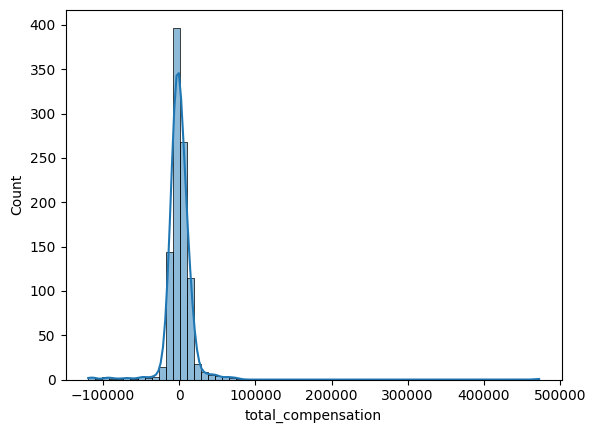

In [29]:
sns.histplot(residuals, kde=True)

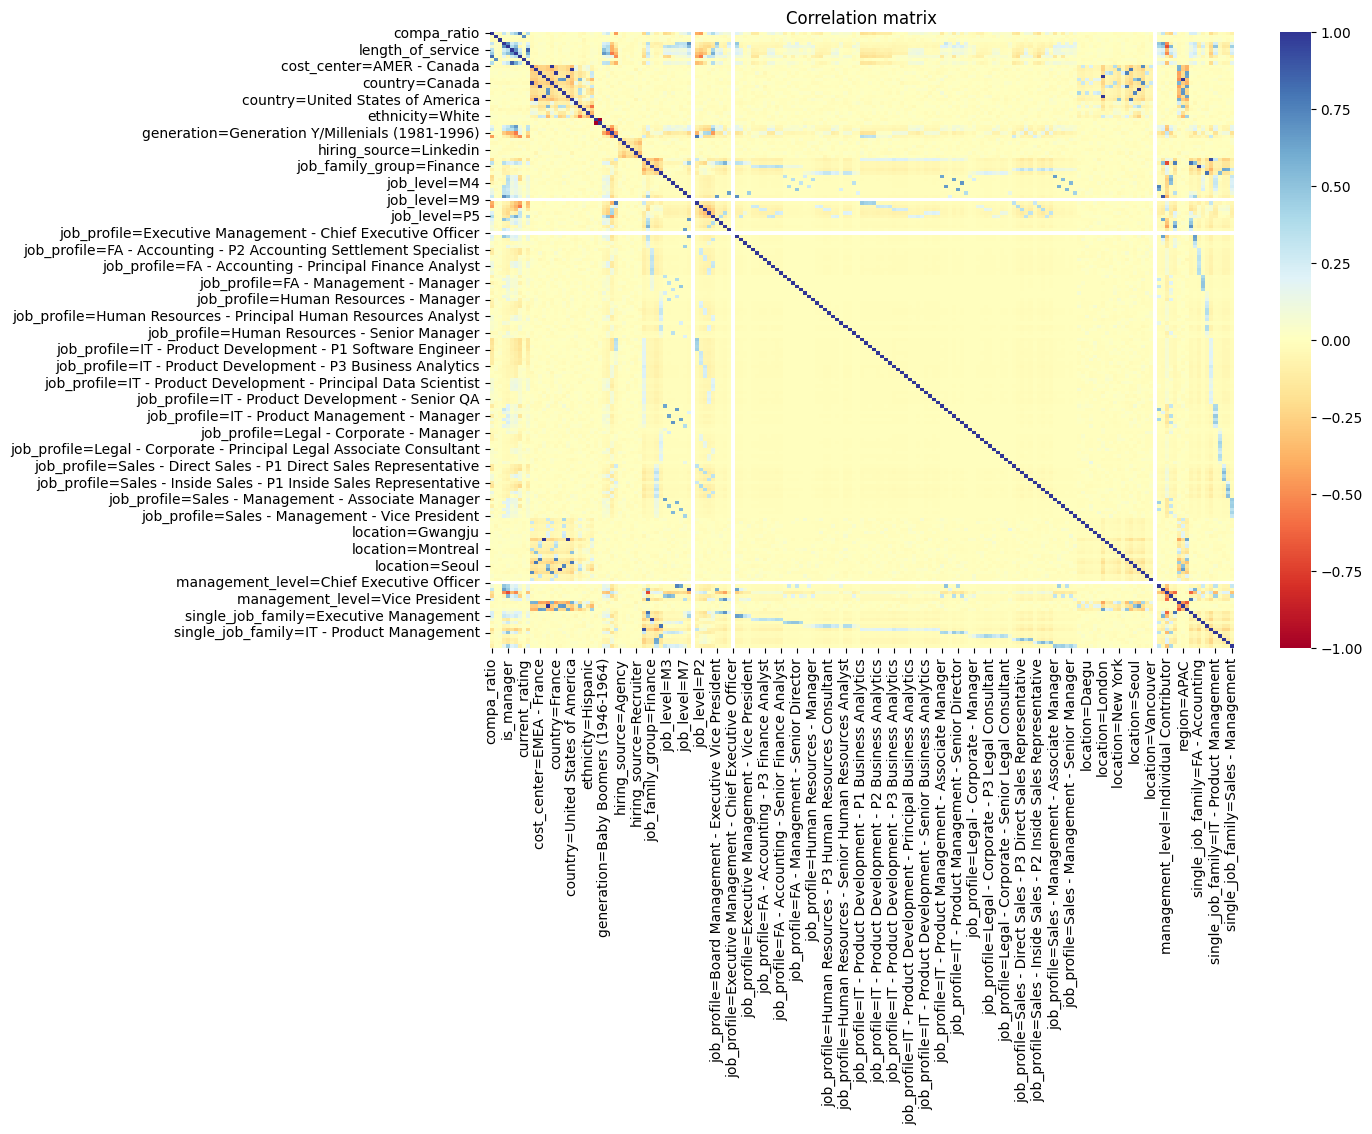

In [30]:
# We broke multicollinearity assumption by using all features
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), annot=False, cmap='RdYlBu', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()
# NOTE: White line represents columns which contain only zeros

# 3) Orthogonal Matching Pursuit

In [34]:
n_coefs = 11
model = sklearn.linear_model.OrthogonalMatchingPursuit(n_nonzero_coefs=n_coefs)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred

# Evaluate the model
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred)

print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.12508973808636736
Root Mean Squared Error: 25115.239688207443
R-squared: 0.9406872778959947


What are the residuals?

In [35]:
residuals.describe()

count      1000.000
mean        -71.508
std       25127.705
min     -136974.590
25%       -9392.462
50%       -2249.060
75%        6910.988
max      465699.425
Name: total_compensation, dtype: float64

How does the target attribute looks like?

<Axes: >

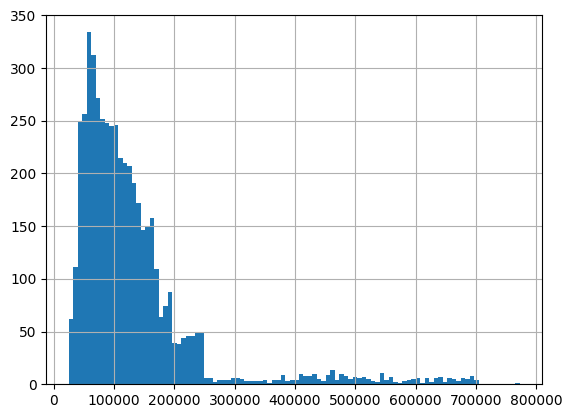

In [36]:
df['total_compensation'].hist(bins=100)

What is the model doing? There is a linear model inside :-).

In [37]:
y_pred = X_test_scaled @ model.coef_ + model.intercept_
y_pred[:5]

array([40012.98749039, 72509.05456051, 26720.48469275, 74277.72802948,
       43852.45827751])

### Use coefficients estimated by OMP to visualize their impact using (e.g.: seaborn, matplotlib). Think about the interpretation of the visualization, especially "age", "job_level -> M8" and "generation -> Baby Boomers (1946 - 1964)".

In [38]:
n_coefs = 11
model = sklearn.linear_model.OrthogonalMatchingPursuit(n_nonzero_coefs=n_coefs)
model.fit(X_train_scaled, y_train)

,n_nonzero_coefs,11
,tol,None
,fit_intercept,True
,precompute,'auto'


/var/folders/_r/b5yd1jqj5dg8_q46vf_wrsgr0000gn/T/ipykernel_91409/9395927.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=selected_features, y=selected_features.index, palette=colors, dodge=False)
/var/folders/_r/b5yd1jqj5dg8_q46vf_wrsgr0000gn/T/ipykernel_91409/9395927.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(selected_features.index)


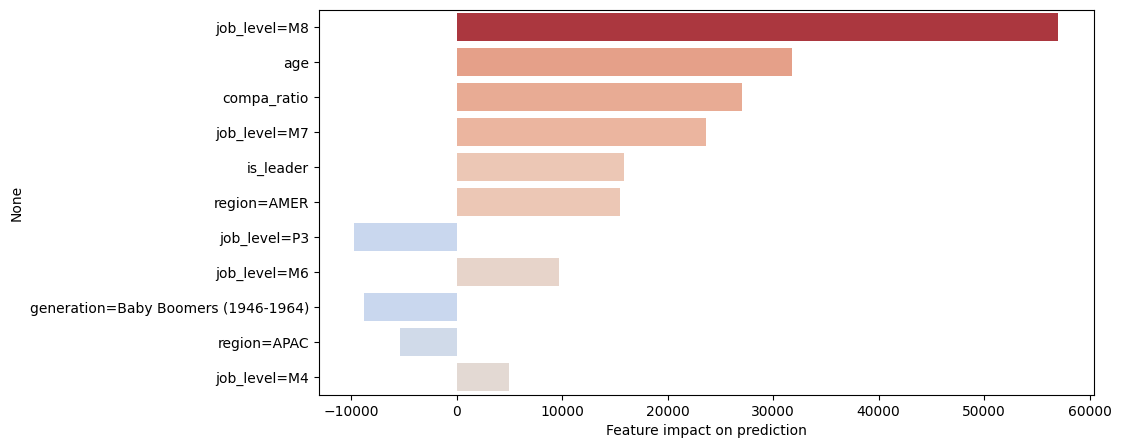

In [39]:
# Visualise the features that have been selected and their respective scores
feature_scores = pd.Series(model.coef_, index=X_data.columns).sort_values(ascending=False, key=lambda x: abs(x))
selected_features = feature_scores[:n_coefs]

f, ax = plt.subplots(figsize=(10, 5))
shades = 31
palette = sns.color_palette('coolwarm', shades)
minmax = np.max([-np.min(selected_features), np.max(selected_features)])
bins = np.linspace(-minmax, minmax, num=shades)
palette_indices = np.digitize(selected_features, bins) - 1
colors = [palette[idx] for idx in palette_indices]

ax = sns.barplot(x=selected_features, y=selected_features.index, palette=colors, dodge=False)
ax.set_yticklabels(selected_features.index)
ax.set_xlabel('Feature impact on prediction')
plt.show()

#### What you can tell about these features?

#### Lets see what a one year change in age can do

In [40]:
X_test.iloc[0:1]

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,age,compa_ratio_range,current_rating,tenure_category,cost_center=AMER - Canada,cost_center=AMER - United States of America,cost_center=EMEA - France,cost_center=EMEA - United Kingdom,cost_center=Global Support - Asia/Pac,country=Canada,country=France,country=Singapore,country=South Korea,country=United Kingdom,country=United States of America,ethnicity=American Indian or Alaska Native,ethnicity=Asian,ethnicity=Black or African American,ethnicity=Hispanic,ethnicity=White,gender=Female,gender=Male,generation=Baby Boomers (1946-1964),generation=Generation X (1965-1980),generation=Generation Y/Millenials (1981-1996),generation=Generation Z (1997 and onwards),hiring_source=Agency,hiring_source=Corporate Website,hiring_source=Internal,hiring_source=Linkedin,hiring_source=Recruiter,hiring_source=Referral,job_family_group=Development,job_family_group=Executive,job_family_group=Finance,job_family_group=Sales,job_family_group=Services,job_level=M2,job_level=M3,job_level=M4,job_level=M5,job_level=M6,job_level=M7,job_level=M8,job_level=M9,job_level=P1,job_level=P2,job_level=P3,job_level=P4,job_level=P5,job_profile=Board Management - Executive Vice President,job_profile=Board Management - Principal Board Associate,job_profile=Board Management - Senior Board Associate,job_profile=Board Management - Vice President,job_profile=Executive Management - Chief Executive Officer,job_profile=Executive Management - Executive Vice President,job_profile=Executive Management - Principal Operations Executive,job_profile=Executive Management - Senior Operations Executive,job_profile=Executive Management - Vice President,job_profile=FA - Accounting - P2 Accounting Settlement Specialist,job_profile=FA - Accounting - P2 Finance Analyst,job_profile=FA - Accounting - P3 Accounting Settlement Specialist,job_profile=FA - Accounting - P3 Finance Analyst,job_profile=FA - Accounting - Principal Accounting Settlement Specialist,job_profile=FA - Accounting - Principal Finance Analyst,job_profile=FA - Accounting - Senior Accounting Settlement Specialist,job_profile=FA - Accounting - Senior Finance Analyst,job_profile=FA - Management - Associate Manager,job_profile=FA - Management - Director,job_profile=FA - Management - Manager,job_profile=FA - Management - Senior Director,job_profile=FA - Management - Senior Manager,job_profile=Human Resources - Associate Manager,job_profile=Human Resources - Director,job_profile=Human Resources - Manager,job_profile=Human Resources - P2 Human Resources Analyst,job_profile=Human Resources - P2 Human Resources Consultant,job_profile=Human Resources - P3 Human Resources Analyst,job_profile=Human Resources - P3 Human Resources Consultant,job_profile=Human Resources - Principal Human Resources Analyst,job_profile=Human Resources - Principal Human Resources Consultant,job_profile=Human Resources - Senior Director,job_profile=Human Resources - Senior Human Resources Analyst,job_profile=Human Resources - Senior Human Resources Consultant,job_profile=Human Resources - Senior Manager,job_profile=Human Resources - Vice President,job_profile=IT - Product Development - P1 Business Analytics,job_profile=IT - Product Development - P1 Data Scientist,job_profile=IT - Product Development - P1 QA,job_profile=IT - Product Development - P1 Software Engineer,job_profile=IT - Product Development - P2 Business Analytics,job_profile=IT - Product Development - P2 Data Scientist,job_profile=IT - Product Development - P2 QA,job_profile=IT - Product Development - P2 Software Engineer,job_profile=IT - Product Development - P3 Business Analytics,job_profile=IT - Product Development - P3 Data Scientist,job_profile=IT - Product Development - P3 QA,job_profile=IT - Product Development - P3 Software Engineer,job_profile=IT - Product Development - Principal Business Analytics,job_profile=IT - Product Development - Principal Data Scientist,job_profile=IT - Product Development - Principal 

In [41]:
pd.DataFrame(X_test_scaled[0:1, :], columns=X_test.columns)

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,age,compa_ratio_range,current_rating,tenure_category,cost_center=AMER - Canada,cost_center=AMER - United States of America,cost_center=EMEA - France,cost_center=EMEA - United Kingdom,cost_center=Global Support - Asia/Pac,country=Canada,country=France,country=Singapore,country=South Korea,country=United Kingdom,country=United States of America,ethnicity=American Indian or Alaska Native,ethnicity=Asian,ethnicity=Black or African American,ethnicity=Hispanic,ethnicity=White,gender=Female,gender=Male,generation=Baby Boomers (1946-1964),generation=Generation X (1965-1980),generation=Generation Y/Millenials (1981-1996),generation=Generation Z (1997 and onwards),hiring_source=Agency,hiring_source=Corporate Website,hiring_source=Internal,hiring_source=Linkedin,hiring_source=Recruiter,hiring_source=Referral,job_family_group=Development,job_family_group=Executive,job_family_group=Finance,job_family_group=Sales,job_family_group=Services,job_level=M2,job_level=M3,job_level=M4,job_level=M5,job_level=M6,job_level=M7,job_level=M8,job_level=M9,job_level=P1,job_level=P2,job_level=P3,job_level=P4,job_level=P5,job_profile=Board Management - Executive Vice President,job_profile=Board Management - Principal Board Associate,job_profile=Board Management - Senior Board Associate,job_profile=Board Management - Vice President,job_profile=Executive Management - Chief Executive Officer,job_profile=Executive Management - Executive Vice President,job_profile=Executive Management - Principal Operations Executive,job_profile=Executive Management - Senior Operations Executive,job_profile=Executive Management - Vice President,job_profile=FA - Accounting - P2 Accounting Settlement Specialist,job_profile=FA - Accounting - P2 Finance Analyst,job_profile=FA - Accounting - P3 Accounting Settlement Specialist,job_profile=FA - Accounting - P3 Finance Analyst,job_profile=FA - Accounting - Principal Accounting Settlement Specialist,job_profile=FA - Accounting - Principal Finance Analyst,job_profile=FA - Accounting - Senior Accounting Settlement Specialist,job_profile=FA - Accounting - Senior Finance Analyst,job_profile=FA - Management - Associate Manager,job_profile=FA - Management - Director,job_profile=FA - Management - Manager,job_profile=FA - Management - Senior Director,job_profile=FA - Management - Senior Manager,job_profile=Human Resources - Associate Manager,job_profile=Human Resources - Director,job_profile=Human Resources - Manager,job_profile=Human Resources - P2 Human Resources Analyst,job_profile=Human Resources - P2 Human Resources Consultant,job_profile=Human Resources - P3 Human Resources Analyst,job_profile=Human Resources - P3 Human Resources Consultant,job_profile=Human Resources - Principal Human Resources Analyst,job_profile=Human Resources - Principal Human Resources Consultant,job_profile=Human Resources - Senior Director,job_profile=Human Resources - Senior Human Resources Analyst,job_profile=Human Resources - Senior Human Resources Consultant,job_profile=Human Resources - Senior Manager,job_profile=Human Resources - Vice President,job_profile=IT - Product Development - P1 Business Analytics,job_profile=IT - Product Development - P1 Data Scientist,job_profile=IT - Product Development - P1 QA,job_profile=IT - Product Development - P1 Software Engineer,job_profile=IT - Product Development - P2 Business Analytics,job_profile=IT - Product Development - P2 Data Scientist,job_profile=IT - Product Development - P2 QA,job_profile=IT - Product Development - P2 Software Engineer,job_profile=IT - Product Development - P3 Business Analytics,job_profile=IT - Product Development - P3 Data Scientist,job_profile=IT - Product Development - P3 QA,job_profile=IT - Product Development - P3 Software Engineer,job_profile=IT - Product Development - Principal Business Analytics,job_profile=IT - Product Development - Principal Data Scientist,job_profile=IT - Product Development - Principal 

In [42]:
X_new_entry = X_test.iloc[0:1].copy()
X_new_entry['age'] += 1

In [43]:
pd.DataFrame(scaler.transform(X_new_entry), columns=X_test.columns)

,compa_ratio,high_performer,high_potential,is_leader,is_manager,length_of_service,age,compa_ratio_range,current_rating,tenure_category,cost_center=AMER - Canada,cost_center=AMER - United States of America,cost_center=EMEA - France,cost_center=EMEA - United Kingdom,cost_center=Global Support - Asia/Pac,country=Canada,country=France,country=Singapore,country=South Korea,country=United Kingdom,country=United States of America,ethnicity=American Indian or Alaska Native,ethnicity=Asian,ethnicity=Black or African American,ethnicity=Hispanic,ethnicity=White,gender=Female,gender=Male,generation=Baby Boomers (1946-1964),generation=Generation X (1965-1980),generation=Generation Y/Millenials (1981-1996),generation=Generation Z (1997 and onwards),hiring_source=Agency,hiring_source=Corporate Website,hiring_source=Internal,hiring_source=Linkedin,hiring_source=Recruiter,hiring_source=Referral,job_family_group=Development,job_family_group=Executive,job_family_group=Finance,job_family_group=Sales,job_family_group=Services,job_level=M2,job_level=M3,job_level=M4,job_level=M5,job_level=M6,job_level=M7,job_level=M8,job_level=M9,job_level=P1,job_level=P2,job_level=P3,job_level=P4,job_level=P5,job_profile=Board Management - Executive Vice President,job_profile=Board Management - Principal Board Associate,job_profile=Board Management - Senior Board Associate,job_profile=Board Management - Vice President,job_profile=Executive Management - Chief Executive Officer,job_profile=Executive Management - Executive Vice President,job_profile=Executive Management - Principal Operations Executive,job_profile=Executive Management - Senior Operations Executive,job_profile=Executive Management - Vice President,job_profile=FA - Accounting - P2 Accounting Settlement Specialist,job_profile=FA - Accounting - P2 Finance Analyst,job_profile=FA - Accounting - P3 Accounting Settlement Specialist,job_profile=FA - Accounting - P3 Finance Analyst,job_profile=FA - Accounting - Principal Accounting Settlement Specialist,job_profile=FA - Accounting - Principal Finance Analyst,job_profile=FA - Accounting - Senior Accounting Settlement Specialist,job_profile=FA - Accounting - Senior Finance Analyst,job_profile=FA - Management - Associate Manager,job_profile=FA - Management - Director,job_profile=FA - Management - Manager,job_profile=FA - Management - Senior Director,job_profile=FA - Management - Senior Manager,job_profile=Human Resources - Associate Manager,job_profile=Human Resources - Director,job_profile=Human Resources - Manager,job_profile=Human Resources - P2 Human Resources Analyst,job_profile=Human Resources - P2 Human Resources Consultant,job_profile=Human Resources - P3 Human Resources Analyst,job_profile=Human Resources - P3 Human Resources Consultant,job_profile=Human Resources - Principal Human Resources Analyst,job_profile=Human Resources - Principal Human Resources Consultant,job_profile=Human Resources - Senior Director,job_profile=Human Resources - Senior Human Resources Analyst,job_profile=Human Resources - Senior Human Resources Consultant,job_profile=Human Resources - Senior Manager,job_profile=Human Resources - Vice President,job_profile=IT - Product Development - P1 Business Analytics,job_profile=IT - Product Development - P1 Data Scientist,job_profile=IT - Product Development - P1 QA,job_profile=IT - Product Development - P1 Software Engineer,job_profile=IT - Product Development - P2 Business Analytics,job_profile=IT - Product Development - P2 Data Scientist,job_profile=IT - Product Development - P2 QA,job_profile=IT - Product Development - P2 Software Engineer,job_profile=IT - Product Development - P3 Business Analytics,job_profile=IT - Product Development - P3 Data Scientist,job_profile=IT - Product Development - P3 QA,job_profile=IT - Product Development - P3 Software Engineer,job_profile=IT - Product Development - Principal Business Analytics,job_profile=IT - Product Development - Principal Data Scientist,job_profile=IT - Product Development - Principal 

In [44]:
y_test[0:1]

4506    44500
Name: total_compensation, dtype: int64

In [45]:
model.predict(X_test_scaled[0:1, :])

array([40012.98749039])

In [46]:
model.predict(scaler.transform(X_new_entry))

array([42974.87222143])

## Run again Linear Regression only for selected features. Did the feature selection resolves original problem?

In [47]:
selected_features.index

Index(['job_level=M8', 'age', 'compa_ratio', 'job_level=M7', 'is_leader',
       'region=AMER', 'job_level=P3', 'job_level=M6',
       'generation=Baby Boomers (1946-1964)', 'region=APAC', 'job_level=M4'],
      dtype='object')

In [49]:
model = sklearn.linear_model.LinearRegression()
model.fit(pd.DataFrame(X_train_scaled, columns=X_train.columns)[selected_features.index], y_train)
y_pred = model.predict(pd.DataFrame(X_test_scaled, columns=X_test.columns)[selected_features.index])
residuals = y_test - y_pred

# Evaluate the model
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred)

print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.12508973808636567
Root Mean Squared Error: 25115.239688206973
R-squared: 0.9406872778959969


# 3) Random Forest and Boruta feature selection

* https://medium.com/geekculture/boruta-feature-selection-explained-in-python-7ae8bf4aa1e7

In [ ]:
# Install package not available in Colab by default
# !pip install boruta

### Specify a base RF model and use it to run Boruta feature selection

In [50]:
from boruta import BorutaPy

In [51]:
# Base RF model specification
rf = sklearn.ensemble.RandomForestRegressor(max_depth=20, random_state=123)

In [52]:
# Boruta feature search
feat_selector = BorutaPy(
    verbose=2,
    estimator=rf,
    n_estimators=20,
    max_iter=25,
    random_state=123
)

feat_selector.fit(np.array(X_train), np.array(y_train))

Iteration: 	1 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	2 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	3 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	4 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	5 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	6 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	7 / 25
Confirmed: 	0
Tentative: 	185
Rejected: 	0
Iteration: 	8 / 25
Confirmed: 	22
Tentative: 	5
Rejected: 	158
Iteration: 	9 / 25
Confirmed: 	22
Tentative: 	5
Rejected: 	158
Iteration: 	10 / 25
Confirmed: 	22
Tentative: 	5
Rejected: 	158
Iteration: 	11 / 25
Confirmed: 	22
Tentative: 	5
Rejected: 	158
Iteration: 	12 / 25
Confirmed: 	22
Tentative: 	3
Rejected: 	160
Iteration: 	13 / 25
Confirmed: 	22
Tentative: 	3
Rejected: 	160
Iteration: 	14 / 25
Confirmed: 	22
Tentative: 	3
Rejected: 	160
Iteration: 	15 / 25
Confirmed: 	22
Tentative: 	3
Rejected: 	160
Iteration: 	16 / 25
Confirmed: 	22
Tentative: 	3
Rejecte

,estimator,RandomForestR...t 0x118999140)
,n_estimators,20
,perc,100
,alpha,0.05
,two_step,True
,max_iter,25
,random_state,RandomState(M...at 0x118999140
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,n_estimators,20


In [53]:
# Get the list of selected features
boruta_selected = []

for i in range(len(feat_selector.support_)):
    if (feat_selector.support_[i] or feat_selector.support_weak_[i]):
        boruta_selected.append(X_train.columns[i])
        print(X_train.columns[i])

compa_ratio
is_leader
is_manager
age
cost_center=Global Support - Asia/Pac
job_level=M4
job_level=M5
job_level=M6
job_level=M7
job_level=M8
job_level=P1
job_level=P2
job_level=P3
job_level=P4
job_level=P5
job_profile=Executive Management - Executive Vice President
job_profile=Executive Management - Vice President
management_level=Director
management_level=Executive Vice President
management_level=Vice President
region=AMER
region=APAC
region=EMEA


In [54]:
print('Number of selected features: ', len(boruta_selected))

Number of selected features:  23


### Run RF model with features selected by Boruta

In [55]:
# Get subsets of explanatory variables only with features that were selected
X_filtered_train = X_train[boruta_selected]
X_filtered_test = X_test[boruta_selected]

In [56]:
# Model specification 
rf = sklearn.ensemble.RandomForestRegressor(n_estimators=50, max_depth=20, random_state=123)

# Fit the model
rf.fit(X_filtered_train, y_train)

# Get predictions
y_pred_BR_sel = rf.predict(X_filtered_test)

In [58]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred_BR_sel)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred_BR_sel)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred_BR_sel)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.004961502884308441
Root Mean Squared Error: 7398.123120025602
R-squared: 0.9948534486445018


### Run RF model with all features

In [59]:
# Model specification 
rf = sklearn.ensemble.RandomForestRegressor(n_estimators=50, max_depth=20, random_state=123)

# Fit the model
rf.fit(X_train, y_train)

# Get predictions
y_pred_rf = rf.predict(X_test)

In [60]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred_rf)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred_rf)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.006767382522046515
Root Mean Squared Error: 7971.37300524934
R-squared: 0.994024978604095


# Tasks
## Task 1: Use a *feature_importance* param in Random Forest (RF) for feature selection
1. Fit RF model without feature selection
2. Select the most important features using variable importance scores
    - Visualize the value of *feature_importance* for attributes
3. Fit the RF model again, now with selected features only

## Task 2: Summarize the insights gained in this analysis
Try some other regression model. You can choose different algorithm or different parameters.

Create a conlusion for this analysis. You can write about something from following list:
- Report the prediction scores achived by various models.
- What features were found important when solving this regression task?

Imagine, you are presenting these results to HR deparment team. Did you get any relevant information for that presentation in this analysis?

In [61]:
rf = sklearn.ensemble.RandomForestRegressor(n_estimators=50, max_depth=20, random_state=123)

# Fit the model
rf.fit(X_train, y_train)

# Get predictions
y_pred_rf = rf.predict(X_test)

In [62]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred_rf)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred_rf)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.006767382522046515
Root Mean Squared Error: 7971.37300524934
R-squared: 0.994024978604095


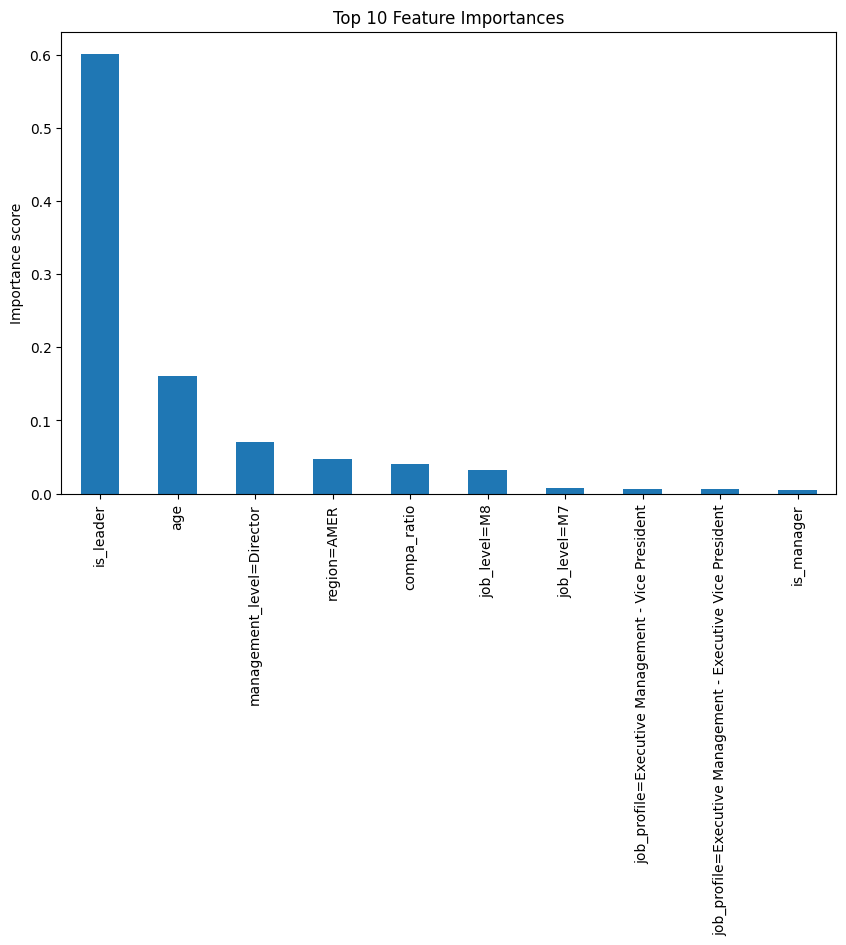

In [67]:
feature_importance = pd.Series(rf.feature_importances_, index=X_data.columns)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance score")
plt.show()

In [89]:
important_features = feature_importance[:30]
important_features

is_leader                                                     0.601
age                                                           0.160
management_level=Director                                     0.071
region=AMER                                                   0.047
compa_ratio                                                   0.040
job_level=M8                                                  0.032
job_level=M7                                                  0.008
job_profile=Executive Management - Vice President             0.007
job_profile=Executive Management - Executive Vice President   0.006
is_manager                                                    0.004
job_level=P4                                                  0.004
job_level=P5                                                  0.003
management_level=Executive Vice President                     0.003
management_level=Vice President                               0.002
job_level=M6                                    

In [90]:
important_feature_names = important_features.index
important_feature_names

Index(['is_leader', 'age', 'management_level=Director', 'region=AMER',
       'compa_ratio', 'job_level=M8', 'job_level=M7',
       'job_profile=Executive Management - Vice President',
       'job_profile=Executive Management - Executive Vice President',
       'is_manager', 'job_level=P4', 'job_level=P5',
       'management_level=Executive Vice President',
       'management_level=Vice President', 'job_level=M6', 'job_level=P1',
       'job_level=M5', 'job_level=P3', 'region=APAC', 'region=EMEA',
       'cost_center=Global Support - Asia/Pac', 'job_level=M4', 'job_level=P2',
       'single_job_family=Sales - Management',
       'generation=Generation X (1965-1980)',
       'job_profile=Sales - Management - Senior Director', 'length_of_service',
       'hiring_source=Corporate Website', 'ethnicity=White', 'country=Canada'],
      dtype='object')

In [91]:
X_filtered_train = X_train[important_feature_names]
X_filtered_test = X_test[important_feature_names]

In [92]:
rf_selected = sklearn.ensemble.RandomForestRegressor(n_estimators=50, max_depth=20, random_state=123)

# Fit the model
rf_selected.fit(X_filtered_train, y_train)

# Get predictions
y_pred_rf = rf_selected.predict(X_filtered_test)

In [120]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred_rf)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred_rf)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.005280699221555363
Root Mean Squared Error: 7032.961458518026
R-squared: 0.9953489642632859


# TASK 2

In [94]:
from sklearn.svm import SVR

In [114]:
svr = SVR(kernel='linear', C=500, gamma=0.001, epsilon=0.01)
svr.fit(X_train_scaled, y_train)

,kernel,'linear'
,degree,3
,gamma,0.001
,coef0,0.0
,tol,0.001
,C,500
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [115]:
y_pred_svr = svr.predict(X_test_scaled)


In [116]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred_svr)
mape = sklearn.metrics.mean_absolute_percentage_error(y_test, y_pred_svr)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Percentage Error (MAPE): 0.07815665190463397
Root Mean Squared Error: 22120.0617644996
R-squared: 0.9539906739006604


In [113]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [1, 10, 100, 500],
    'gamma': [0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(SVR(kernel='linear'), param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best RMSE:", np.sqrt(-grid.best_score_))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'C': 500, 'epsilon': 0.01, 'gamma': 0.001}
Best RMSE: 20172.149106093966


Cílem této části bylo porovnat různé regresní modely pro predikci celkové odměny zaměstnanců (total compensation) na základě dostupných dat z oblasti HR.

Nejprve byl použit Random Forest Regressor s výchozí sadou všech atributů. Tento model dosáhl velmi dobré přesnosti —
RMSE = 7 971.37 a R² = 0.994, což znamená, že vysvětluje přibližně 99 % variability cílové proměnné.

Následně byl proveden výběr nejdůležitějších atributů (feature selection) na základě jejich důležitosti v modelu. Po ponechání pouze top 30 atributů model dosáhl ještě lepších výsledků:
RMSE = 7 032.96 a R² = 0.995.
To potvrzuje, že menší počet dobře zvolených proměnných nejen zjednodušuje model, ale může také mírně zvýšit jeho přesnost.

Nakonec byl vyzkoušen model podpůrných vektorů (SVR) s lineárním jádrem. Tento model dosáhl výsledků
RMSE = 22 120.06 a R² = 0.954, tedy nižší přesnosti než Random Forest. Přesto poskytuje užitečné srovnání, protože ukazuje, že vztahy mezi proměnnými nejsou čistě lineární a nelineární modely (jako Random Forest) si s nimi poradí lépe.

Z analýzy významnosti jednotlivých proměnných vyplývá, že největší vliv na výši mzdy mají následující faktory:

is_leader – zda zaměstnanec zastává vedoucí pozici,

age – věk zaměstnance,

management_level=Director – úroveň řízení,

region=AMER – geografická oblast,

compa_ratio – poměr platu vůči průměru dané pozice.

Dalšími významnými, i když méně zásadními, faktory byly pracovní úrovně (job_level=M8, job_level=M7) a pozice typu Executive Management.

Z pohledu HR oddělení tato zjištění potvrzují, že odměňování je nejvíce ovlivněno manažerskou úrovní, věkem a lokalitou. Analýza tak může posloužit jako podklad pro nastavení férovějších mzdových politik a lepší porozumění tomu, které faktory nejvíce přispívají k rozdílům v kompenzaci zaměstnanců.